# Sample Cleaning Review

## Goal

This notebook reviews the cleaned 500-record MVP sample after normalization, manual anomaly review, and QA.

The review checks:

- row count;
- final schema;
- ID uniqueness;
- controlled vocabulary status;
- manual anomaly decisions;
- missing values;
- basic demographic and settlement-level summaries.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("..").resolve() if Path.cwd().name == "notebooks" else Path.cwd()
DATA_SAMPLE = PROJECT_ROOT / "data" / "sample"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
QA_DIR = PROJECT_ROOT / "outputs" / "qa"
CHART_DIR = PROJECT_ROOT / "outputs" / "charts"
CHART_DIR.mkdir(parents=True, exist_ok=True)

clean_path = DATA_PROCESSED / "clean_sample_500.csv"
raw_path = DATA_SAMPLE / "raw_extracted_sample_500.csv"
qa_json_path = QA_DIR / "sample_500_qa_report.json"
manual_decisions_path = QA_DIR / "manual_review_decisions.csv"
anomaly_doc_path = QA_DIR / "anomaly_review_final_documentation.md"

print("Project root:", PROJECT_ROOT)
print("Clean sample exists:", clean_path.exists())
print("QA JSON exists:", qa_json_path.exists())

Project root: /mnt/data/chekhov_notebook_repo
Clean sample exists: True
QA JSON exists: True


## Load cleaned sample and QA report

In [2]:
clean = pd.read_csv(clean_path)
with open(qa_json_path, "r", encoding="utf-8") as f:
    qa = json.load(f)

clean.shape, qa

((500, 23),
 {'row_count': 500,
  'unknown_origin_places': [],
  'unknown_legal_statuses': [],
  'unknown_family_statuses': [],
  'unknown_religions': [],
  'unresolved_source_anomalies': [],
  'confirmed_source_anomalies': [{'person_id': 'P000178',
    'source_position_id': '3-30-030-0040',
    'page_number': '425',
    'settlement': 'Поро-ан-Томари',
    'name_raw': 'Андрей Федоров Савельев',
    'field': 'religion',
    'value': '1882',
    'reason': 'religion field contains a year-like value; probable source misprint'}],
  'rule_updates': [{'field': 'religion/occupation and other text fields with square-bracket restoration',
    'rule': 'Remove extraction spaces before square-bracketed restored word parts before removing brackets.',
    'example': 'Правосл [авного] -> Православного -> Православное'},
   {'field': 'origin_place',
    'rule': 'Map Каменецк-Подольская to Подольская губерния using MAIN_GUBERNIAS_1890.',
    'example': 'Каменецк-Подольская -> Подольская губерния'},
   {

In [3]:
clean.head(3)

,person_id,source_position_id,district_code,district,settlement_order,settlement,person_order_in_settlement,page_number,household_number,legal_status,name_raw,family_status,age,religion,origin_place,arrival_year,occupation,literacy,marriage_status,allowance_status,illness,comments,notes_raw
0,P000001,3-28-001-0001,3,Корсаковский,28,Маука,1,413,1,Крестьянин из ссыльных,Иван Вардзинский,Хозяин,40.0,Католическое,Плоцкая губерния,1879.0,Печник.,грамотен,NaN,False,NaN,NaN,РГБ № 6810
1,P000002,3-28-002-0002,3,Корсаковский,28,Маука,2,413,2,Поселенец,Никита Панов,Хозяин,50.0,Православное,Самарская губерния,NaN,NaN,грамотен,NaN,NaN,NaN,NaN,РГБ № 6811
2,P000003,3-28-003-0003,3,Корсаковский,28,Маука,3,413,3,Поселенец,Прохор Титов,Хозяин,34.0,Православное,Тульская губерния,NaN,NaN,NaN,NaN,NaN,NaN,NaN,РГБ № 6812


## Final schema check

The final cleaned CSV should follow the flat person-level schema: one row = one person.

In [4]:
expected_final_columns = [
    "person_id", "source_position_id", "district_code", "district", "settlement_order",
    "settlement", "person_order_in_settlement", "page_number", "household_number",
    "legal_status", "name_raw", "family_status", "age", "religion", "origin_place",
    "arrival_year", "occupation", "literacy", "marriage_status", "allowance_status",
    "illness", "comments", "notes_raw"
]

schema_check = pd.DataFrame({
    "check": [
        "row_count_is_500",
        "all_expected_columns_present",
        "no_extra_columns",
        "person_id_unique",
        "source_position_id_unique",
        "page_number_present",
    ],
    "result": [
        len(clean) == 500,
        set(expected_final_columns).issubset(clean.columns),
        set(clean.columns).issubset(expected_final_columns),
        clean["person_id"].is_unique,
        clean["source_position_id"].is_unique,
        clean["page_number"].notna().all(),
    ]
})
schema_check

,check,result
0,row_count_is_500,True
1,all_expected_columns_present,True
2,no_extra_columns,True
3,person_id_unique,True
4,source_position_id_unique,True
5,page_number_present,True


## QA report summary

After the final review round, unresolved controlled-vocabulary issues should be zero. One confirmed source anomaly remains preserved as printed.

In [5]:
qa_summary = pd.DataFrame([
    {"metric": "row_count", "value": qa.get("row_count")},
    {"metric": "unknown_origin_places", "value": len(qa.get("unknown_origin_places", []))},
    {"metric": "unknown_legal_statuses", "value": len(qa.get("unknown_legal_statuses", []))},
    {"metric": "unknown_family_statuses", "value": len(qa.get("unknown_family_statuses", []))},
    {"metric": "unknown_religions", "value": len(qa.get("unknown_religions", []))},
    {"metric": "unresolved_source_anomalies", "value": len(qa.get("unresolved_source_anomalies", []))},
    {"metric": "confirmed_source_anomalies", "value": len(qa.get("confirmed_source_anomalies", []))},
])
qa_summary

,metric,value
0,row_count,500
1,unknown_origin_places,0
2,unknown_legal_statuses,0
3,unknown_family_statuses,0
4,unknown_religions,0
5,unresolved_source_anomalies,0
6,confirmed_source_anomalies,1


In [6]:
pd.DataFrame(qa.get("confirmed_source_anomalies", []))

,person_id,source_position_id,page_number,settlement,name_raw,field,value,reason
0,P000178,3-30-030-0040,425,Поро-ан-Томари,Андрей Федоров Савельев,religion,1882,religion field contains a year-like value; pro...


## Manual anomaly review decisions

These records were reviewed manually after automated QA. The decision log supports reproducibility and auditability.

In [7]:
if manual_decisions_path.exists():
    manual_decisions = pd.read_csv(manual_decisions_path)
    display(manual_decisions)
else:
    print("No manual_review_decisions.csv found.")

,person_id,source_position_id,page_number,settlement,name_raw,field,source_value,decision,action,status,notes
0,P000128,3-29-037-0090,420,Пост Корсаковский,Владимир Васильев Попов,legal_status,Сс[ылно]каторжный,source typo / spelling variant,normalize to Ссыльнокаторжный,resolved,Add this variant to legal_status normalization...
1,P000178,3-30-030-0040,425,Поро-ан-Томари,Андрей Федоров Савельев,religion,1882,confirmed source typo in original PDF,preserve printed value in religion; keep as co...,confirmed_source_anomaly,Printed field 6 contains 1882; field 8 also co...
2,P000245,3-33-013-0024,429,Третья Падь,Анна Андреева Рудзит,category_code,name field printed as 5.; should be 4.,confirmed source category-code typo,manually assign name/family_status/age/religio...,resolved,age set to 0 and comments set to 4 месяца.
3,P000366,3-35-027-0046,436,Лютога,Аграфена Балаховская,category_code,field 3 contains name; legal_status is absent ...,confirmed source category-code typo / missing ...,leave legal_status blank; manually assign name...,resolved,Do not infer legal_status.
4,P000423,3-38-001-0001,440,Лиственичное,Захар Владимиров Владимиров,religion,Правосл авное,spacing artifact / normalization variant,normalize to Православное,resolved,Similar source text was normalized correctly i...
5,P000426,3-38-004-0004,440,Лиственичное,Егор Васильев Зипов,category_code,"field numbering shifted: name marked as 5., ag...",confirmed source category-code shift,manually assign legal_status/name/family_statu...,resolved,arrival_year left blank because no source fiel...
6,P000143,3-30-003-0005,424,Поро-ан-Томари,Екатерина Аузинг,origin_place,Курляндского,source inflection / origin-place normalization,normalize to Курляндская губерния,resolved,Mapped using MAIN_GUBERNIAS_1890 controlled re...
7,P000452,3-39-009-0015,441,Хомутовка,Петр Иванов Побережнюк,origin_place,Каменецк-Подольская,source variant / origin-place normalization,normalize to Подольская губерния,resolved,Mapped using MAIN_GUBERNIAS_1890 controlled re...


## Reviewed anomaly records in the clean sample

This cell verifies final values for records discussed during manual anomaly review.

In [8]:
reviewed_ids = ["P000128", "P000178", "P000245", "P000366", "P000423", "P000426", "P000143", "P000452"]
cols = [
    "person_id", "source_position_id", "page_number", "settlement", "household_number",
    "legal_status", "name_raw", "family_status", "age", "religion", "origin_place",
    "arrival_year", "literacy", "marriage_status", "allowance_status", "comments", "notes_raw"
]
clean.loc[clean["person_id"].isin(reviewed_ids), cols]

,person_id,source_position_id,page_number,settlement,household_number,legal_status,name_raw,family_status,age,religion,origin_place,arrival_year,literacy,marriage_status,allowance_status,comments,notes_raw
127,P000128,3-29-037-0090,420,Пост Корсаковский,37,Ссыльнокаторжный,Владимир Васильев Попов,Жилец,29.0,Православное,Пензенская губерния,1887.0,грамотен,холост,True,NaN,РГБ № 6982
142,P000143,3-30-003-0005,424,Поро-ан-Томари,3,Ссыльнокаторжная,Екатерина Аузинг,Сожительница,32.0,Лютеранское,Курляндская губерния,1887.0,грамотен,вдов,True,NaN,РГБ № 5797
177,P000178,3-30-030-0040,425,Поро-ан-Томари,30,Поселенец,Андрей Федоров Савельев,Хозяин,60.0,1882,Симбирская губерния,1882.0,грамотен,женат на родине,False,NaN,РГБ № 5829
244,P000245,3-33-013-0024,429,Третья Падь,13,Дочь поселенца,Анна Андреева Рудзит,Дочь,0.0,Православное,На Сахалине,NaN,NaN,NaN,False,4 месяца,РГБ № 4568
365,P000366,3-35-027-0046,436,Лютога,27,NaN,Аграфена Балаховская,Незаконнорожденная дочь,12.0,Православное,NaN,NaN,неграмотен,NaN,NaN,NaN,РГБ № 5775
422,P000423,3-38-001-0001,440,Лиственичное,1,Поселенец,Захар Владимиров Владимиров,Хозяин,36.0,Православное,Смоленская губерния,1885.0,неграмотен,женат на родине,True,NaN,РГБ № 6470
425,P000426,3-38-004-0004,440,Лиственичное,4,Поселенец,Егор Васильев Зипов,Хозяин,53.0,Православное,Орловская губерния,NaN,неграмотен,холост,True,NaN,РГБ № 6473
451,P000452,3-39-009-0015,441,Хомутовка,9,Поселенец,Петр Иванов Побережнюк,Хозяин,33.0,Православное,Подольская губерния,1881.0,грамотен,холост,False,NaN,РГБ № 6448


## Missing-value review

Not all missing values are errors. Some fields are absent in the original records. This table helps identify fields that need interpretation before full-scale extraction.

In [9]:
missing_summary = (
    clean.isna().sum()
    .rename("missing_count")
    .reset_index()
    .rename(columns={"index": "field"})
)
missing_summary["missing_pct"] = (missing_summary["missing_count"] / len(clean) * 100).round(1)
missing_summary.sort_values("missing_pct", ascending=False)

,field,missing_count,missing_pct
20,illness,496,99.2
21,comments,435,87.0
16,occupation,400,80.0
15,arrival_year,183,36.6
18,marriage_status,153,30.6
17,literacy,120,24.0
19,allowance_status,39,7.8
12,age,33,6.6
14,origin_place,30,6.0
11,family_status,8,1.6


## Controlled vocabulary distributions

These summaries are useful before building Tableau dashboards or SQL aggregate tables.

In [10]:
for field in ["legal_status", "family_status", "religion", "literacy", "marriage_status", "allowance_status"]:
    print("\n" + "=" * 80)
    print(field)
    display(clean[field].value_counts(dropna=False).rename_axis(field).reset_index(name="records").head(30))


legal_status


,legal_status,records
0,Поселенец,252
1,Ссыльнокаторжная,75
2,Ссыльнокаторжный,28
3,Крестьянин из ссыльных,24
4,Поселка,20
5,Дочь ссыльнокаторжной,16
6,Дочь поселенца,15
7,Сын ссыльнокаторжной,15
8,Женщина свободного состояния,11
9,Сын поселенца,11



family_status


,family_status,records
0,Хозяин,284
1,Сожительница,75
2,Незаконнорожденная дочь,24
3,Жена,23
4,Незаконнорожденный сын,22
5,Дочь,19
6,Сын,15
7,Жилец,10
8,NaN,8
9,Хозяйка,7



religion


...

,literacy,records
0,неграмотен,220
1,грамотен,160
2,NaN,120



marriage_status


,marriage_status,records
0,NaN,153
1,женат на родине,141
2,холост,136
3,вдов,39
4,женат на Сахалине,31



allowance_status


,allowance_status,records
0,False,271
1,True,190
2,NaN,39


## Settlement-level summary

In [11]:
settlement_summary = (
    clean.groupby(["district", "settlement"], dropna=False)
    .agg(
        records=("person_id", "count"),
        unique_households=("household_number", "nunique"),
        median_age=("age", "median"),
        children_under_15=("age", lambda s: int((s < 15).sum())),
    )
    .reset_index()
    .sort_values("records", ascending=False)
)
settlement_summary

,district,settlement,records,unique_households,median_age,children_under_15
9,Корсаковский,Пост Корсаковский,100,41,33.0,8
10,Корсаковский,Соловьевка,69,26,31.5,13
8,Корсаковский,Поро-ан-Томари,67,47,42.0,7
4,Корсаковский,Лютога,53,33,30.5,6
5,Корсаковский,Маука,38,33,33.0,1
12,Корсаковский,Хомутовка,38,25,34.0,3
11,Корсаковский,Третья Падь,30,17,29.0,7
6,Корсаковский,Мицулька,25,10,28.0,7
0,Корсаковский,Большая Елань,25,17,31.0,3
2,Корсаковский,Голый Мыс,24,23,32.0,0


## First exploratory charts

These quick charts are not the final Tableau dashboard. They are sanity checks for the cleaned MVP sample.

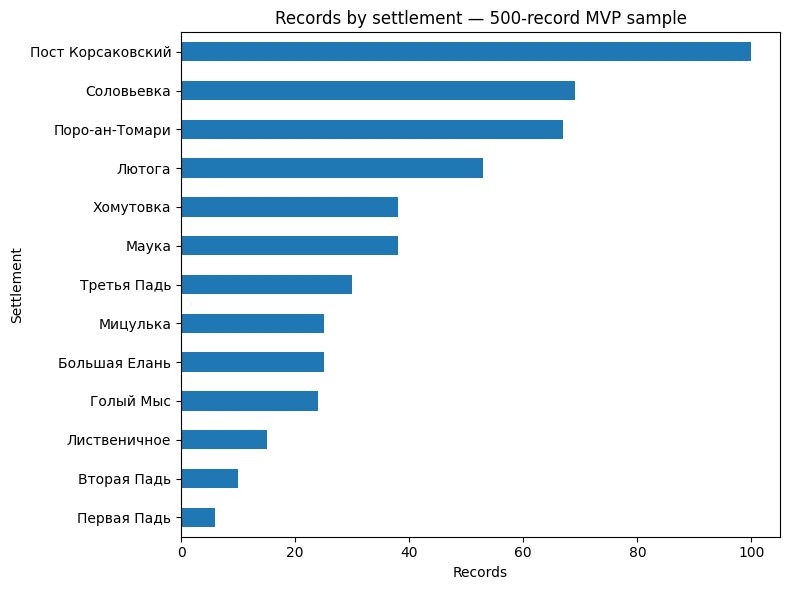

In [12]:
ax = clean["settlement"].value_counts().sort_values().plot(kind="barh", figsize=(8, 6))
ax.set_title("Records by settlement — 500-record MVP sample")
ax.set_xlabel("Records")
ax.set_ylabel("Settlement")
plt.tight_layout()
plt.savefig(CHART_DIR / "records_by_settlement.png", dpi=150)
plt.show()

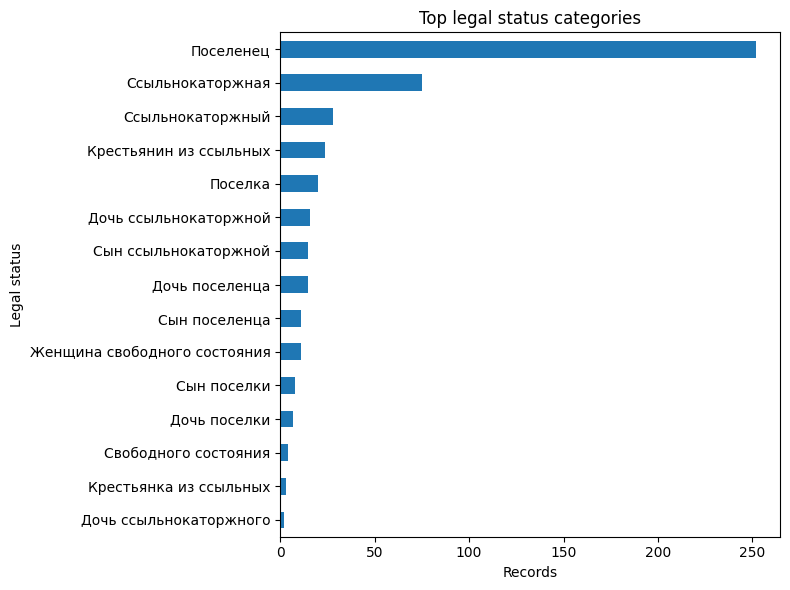

In [13]:
ax = clean["legal_status"].value_counts().head(15).sort_values().plot(kind="barh", figsize=(8, 6))
ax.set_title("Top legal status categories")
ax.set_xlabel("Records")
ax.set_ylabel("Legal status")
plt.tight_layout()
plt.savefig(CHART_DIR / "top_legal_status_categories.png", dpi=150)
plt.show()

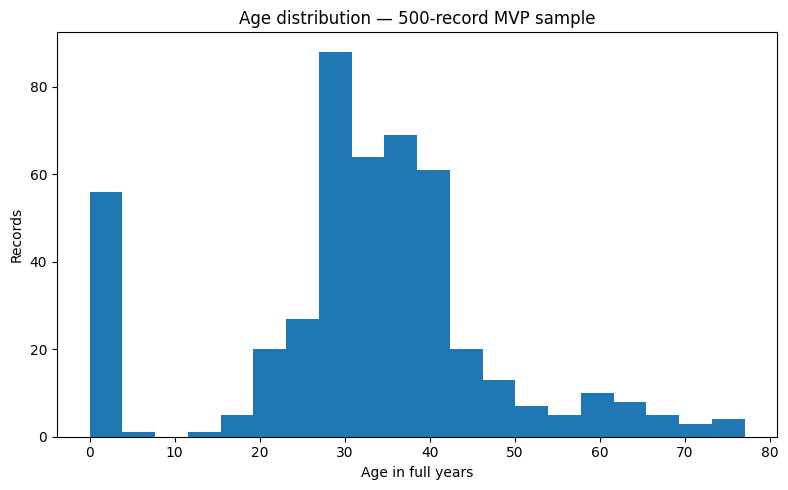

In [14]:
age = clean["age"].dropna()
ax = age.plot(kind="hist", bins=20, figsize=(8, 5))
ax.set_title("Age distribution — 500-record MVP sample")
ax.set_xlabel("Age in full years")
ax.set_ylabel("Records")
plt.tight_layout()
plt.savefig(CHART_DIR / "age_distribution.png", dpi=150)
plt.show()

## Data exports for next stages

The cleaned sample is ready for:

- SQL table creation;
- Tableau dashboard prototyping;
- full-pipeline scaling after the same QA checks are applied to the remaining records.

In [15]:
# Optional aggregate exports for SQL/Tableau prototyping.
summary_dir = PROJECT_ROOT / "outputs" / "summary_tables"
summary_dir.mkdir(parents=True, exist_ok=True)

settlement_summary.to_csv(summary_dir / "settlement_summary_sample_500.csv", index=False)
clean["legal_status"].value_counts(dropna=False).rename_axis("legal_status").reset_index(name="records").to_csv(
    summary_dir / "legal_status_summary_sample_500.csv", index=False
)
clean["origin_place"].value_counts(dropna=False).rename_axis("origin_place").reset_index(name="records").to_csv(
    summary_dir / "origin_place_summary_sample_500.csv", index=False
)

print("Exported summary tables to:", summary_dir)

Exported summary tables to: /mnt/data/chekhov_notebook_repo/outputs/summary_tables


## Cleaning-review conclusion

The 500-record MVP sample passes the current QA success criteria:

- 500 rows are present;
- `person_id` values are unique;
- `source_position_id` values are unique;
- unknown legal statuses = 0;
- unknown family statuses = 0;
- unknown religions = 0;
- unknown origin places = 0;
- unresolved source anomalies = 0;
- confirmed source anomalies are documented.

Next recommended step:

```text
scale the pipeline to the full uploaded PDF section
↓
repeat QA
↓
build SQL analysis tables
↓
start Tableau dashboard prototype
```